In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")



In [4]:
diabetes_dataset = pd.read_csv("./data/diabetes.csv")
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
diabetes_dataset['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [ ]:
diabetes_dataset.groupby("Outcome").mean() # based on this, thee model will learn

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


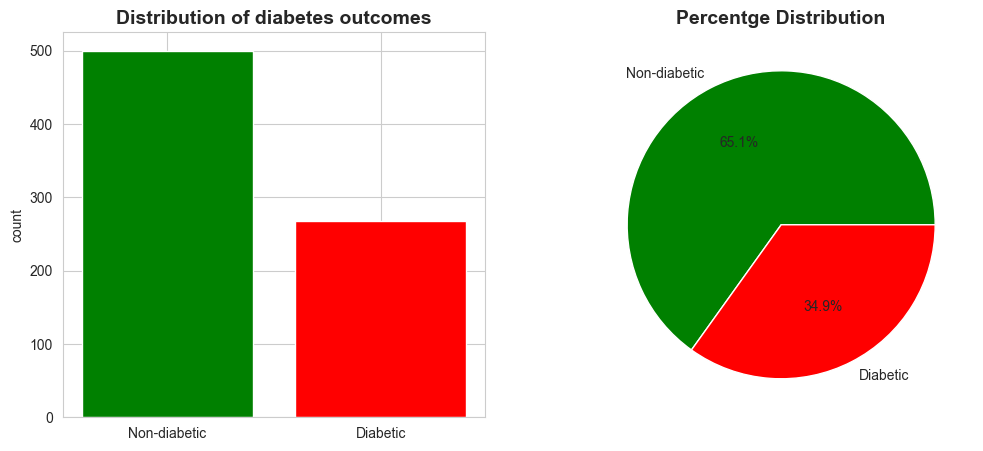

In [11]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
outcome_counts = diabetes_dataset["Outcome"].value_counts()
plt.bar(['Non-diabetic', 'Diabetic'], outcome_counts, color=['green', 'red'])
plt.title('Distribution of diabetes outcomes', fontsize=14, fontweight='bold')
plt.ylabel('count')


plt.subplot(1,2,2)
plt.pie(outcome_counts.values, labels=['Non-diabetic', 'Diabetic'], autopct='%1.1f%%', colors=['green', 'red'])
plt.title('Percentge Distribution', fontsize=14, fontweight='bold')
plt.show()

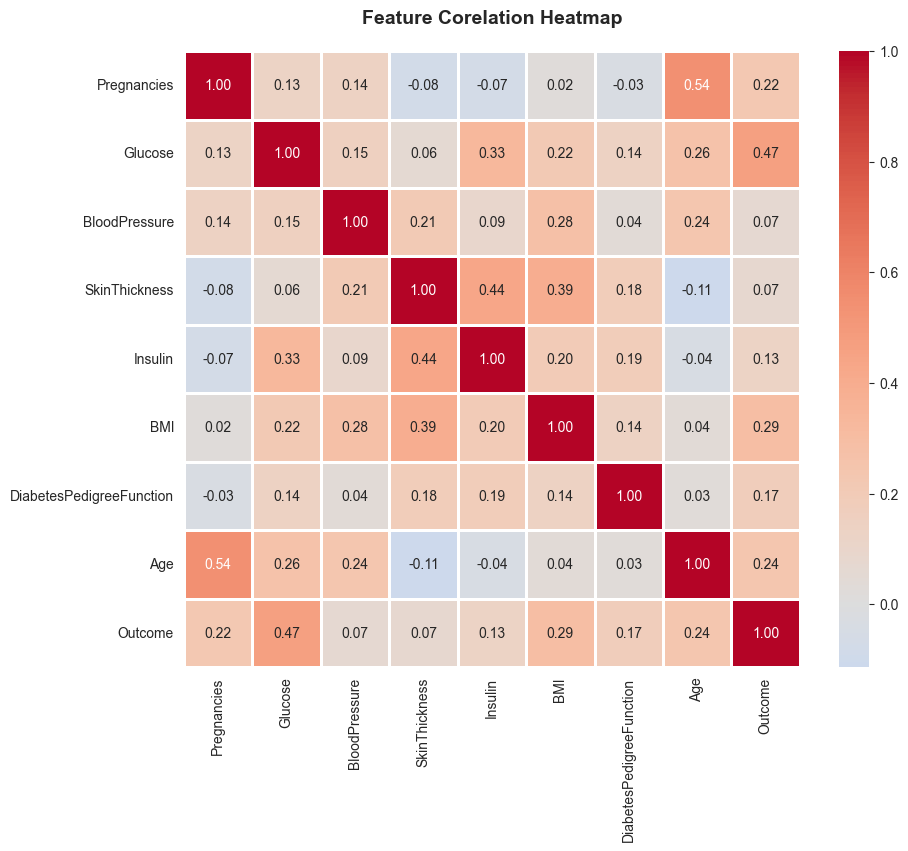

In [12]:
plt.figure(figsize=(10, 8))
corealation = diabetes_dataset.corr()
sns.heatmap(corealation, annot=True, cmap='coolwarm', center=0, square=True, linewidth=1, fmt='.2f')
plt.title("Feature Corelation Heatmap", fontsize=14, pad=20, fontweight='bold')
plt.show()

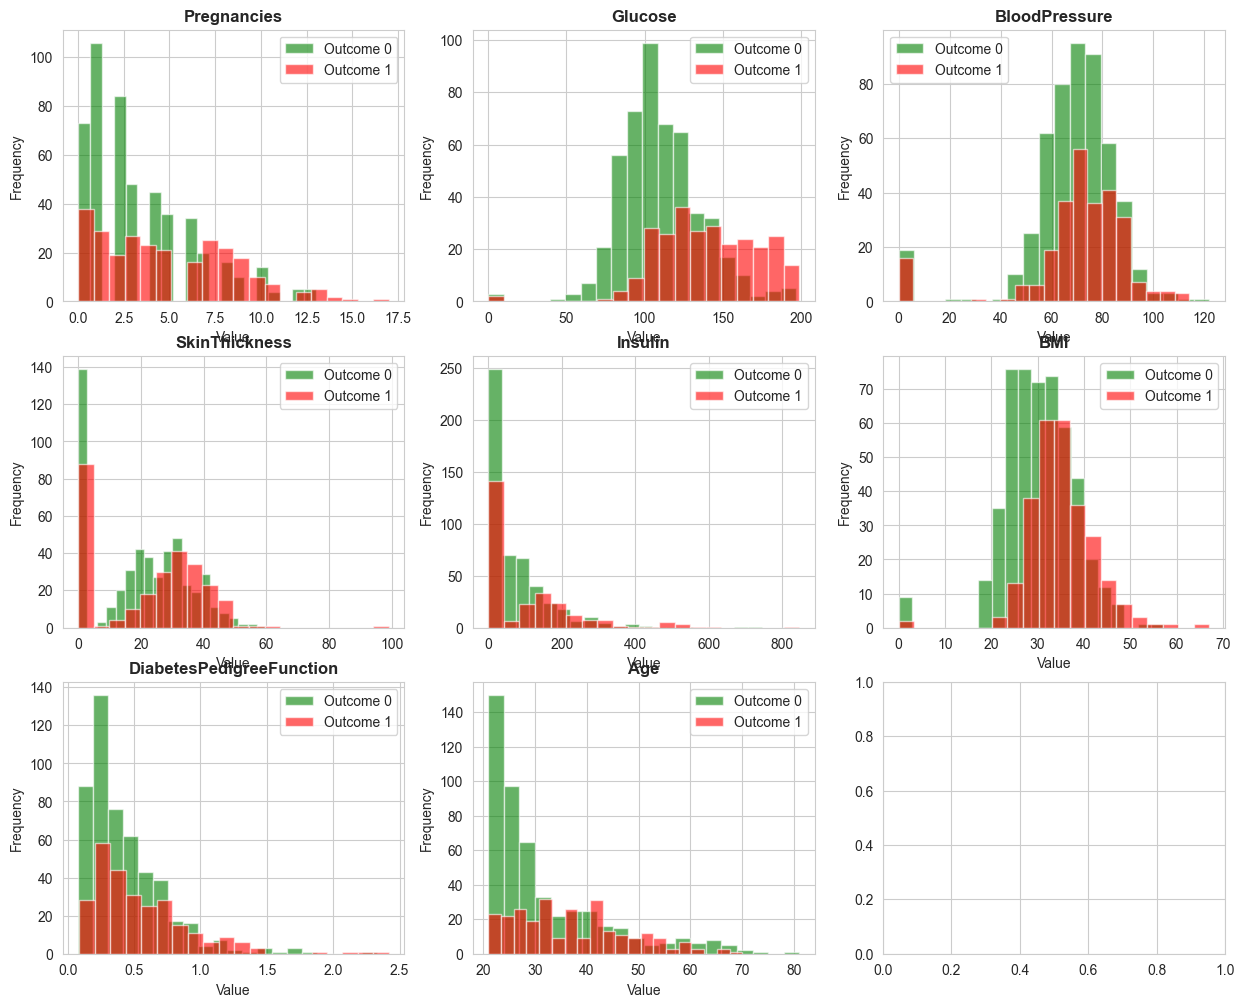

In [15]:
# Feature distribution visualization


fig, axes = plt.subplots(3, 3,figsize=(15, 12))
features = diabetes_dataset.columns[:-1]

for i, feature in enumerate(features):
    r, c = i // 3, i % 3
    for outcome in [0, 1]:
        data = diabetes_dataset[diabetes_dataset['Outcome'] == outcome][feature]
        axes[r,c].hist(data, alpha=0.6, bins=20, label=f"Outcome {outcome}", color=['green', 'red'][outcome])
        axes[r, c].set_title(feature, fontweight='bold')
        axes[r,c].set_xlabel('Value')
        axes[r,c].set_ylabel('Frequency')
        axes[r,c].legend()

plt.show()

In [18]:
X = diabetes_dataset.drop(columns='Outcome', axis=1)
Y = diabetes_dataset['Outcome']
Y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

by standarization, mean = 0 & std_dev = 1.
This is important beacuse, the model shouldn't think the glucose
count is more important just beacuse the value is high, so i want the model
treat the data fairly by standarzing all features are in same scale 




In [19]:
scalar = StandardScaler()
X = scalar.fit_transform(X)
X

array([[ 0.63994726,  0.84832379,  0.14964075, ...,  0.20401277,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.12339636, -0.16054575, ..., -0.68442195,
        -0.36506078, -0.19067191],
       [ 1.23388019,  1.94372388, -0.26394125, ..., -1.10325546,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 ,  0.00330087,  0.14964075, ..., -0.73518964,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.1597866 , -0.47073225, ..., -0.24020459,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.8730192 ,  0.04624525, ..., -0.20212881,
        -0.47378505, -0.87137393]], shape=(768, 8))

In [20]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

print(X.shape, x_train.shape, x_test.shape)

(768, 8) (614, 8) (154, 8)


In [21]:
classifier = svm.SVC(kernel='linear', probability=True)
classifier.fit(x_train, y_train)

SVC(kernel='linear', probability=True)

In [22]:
x_train_prediction = classifier.predict(x_train)
training_acc = accuracy_score(x_train_prediction, y_train)
training_acc

0.7866449511400652

In [23]:
x_test_prediction = classifier.predict(x_test)
training_acc = accuracy_score(x_test_prediction, y_test)
training_acc

0.7727272727272727

In [24]:
precision = precision_score(y_test, x_test_prediction)
recall = recall_score(y_test, x_test_prediction)
f1 = f1_score(y_test, x_test_prediction)

print(precision,recall, f1)

0.7567567567567568 0.5185185185185185 0.6153846153846154


In [25]:
cm_svm = confusion_matrix(y_test, x_test_prediction)
cm_svm

array([[91,  9],
       [26, 28]])

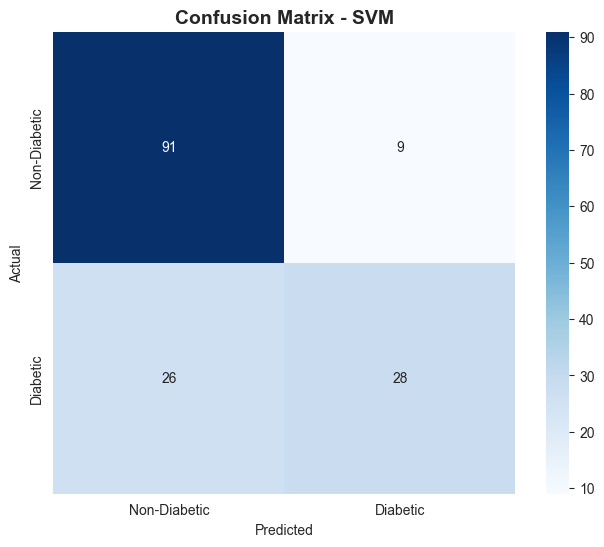

In [27]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d',
            cmap='Blues', square=True,
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])

plt.title("Confusion Matrix - SVM", fontsize=14, fontweight='bold')
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [28]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=2)
rf_classifier.fit(x_train, y_train)

RandomForestClassifier(random_state=2)

In [29]:
x_train_prediction_rf = rf_classifier.predict(x_train)

In [30]:
training_acc_rf = accuracy_score(x_train_prediction_rf, y_train)
training_acc_rf

1.0

In [32]:
x_test_prediction_rf = rf_classifier.predict(x_test)
test_acc_rf = accuracy_score(x_test_prediction_rf, y_test)
test_acc_rf

0.7272727272727273

In [33]:
precision_rf = precision_score(y_test, x_test_prediction_rf)
recall_rf = recall_score(y_test, x_test_prediction_rf)
f1_rf = f1_score(y_test, x_test_prediction_rf)

print(precision_rf, recall_rf, f1_rf)

0.65 0.48148148148148145 0.5531914893617021


In [34]:
cm_rf = confusion_matrix(y_test, x_test_prediction_rf)
cm_rf

array([[86, 14],
       [28, 26]])

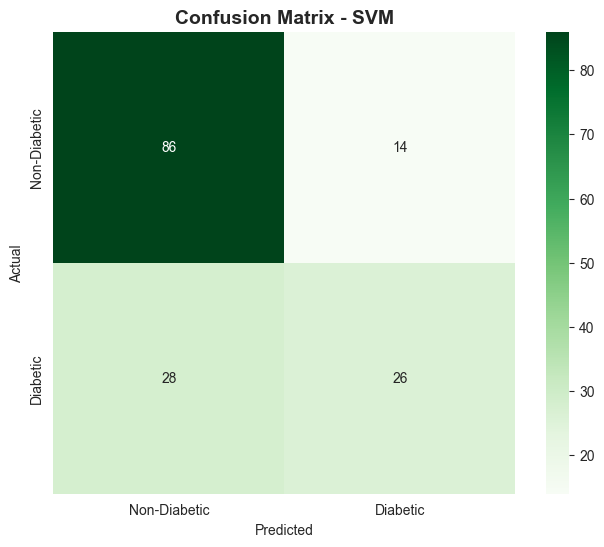

In [37]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d',
            cmap='Greens', square=True,
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])

plt.title("Confusion Matrix - SVM", fontsize=14, fontweight='bold')
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [39]:
print("<-----.x.Models Accuracy Scores.x.------>")
print(f"SVM: {training_acc}")
print(f"Random Forest: {test_acc_rf}")

<-----.x.Models Accuracy Scores.x.------>
SVM: 0.7727272727272727
Random Forest: 0.7272727272727273


In [40]:
joblib.dump(classifier, 'diabetes_model.pkl')

['diabetes_model.pkl']

In [48]:
joblib.dump(scalar, 'scalar_svm.pkl')

['scalar_svm.pkl']

In [49]:
input_data = (5,166,72,19,175,25.8,0.587,51)
ip_num_arr = np.asarray(input_data)
reshape = ip_num_arr.reshape(1, -1)

std_data = scalar.transform(reshape)
predict = classifier.predict(std_data)
predict

array([1])